In [69]:
import pandas as pd
import numpy as np
df = pd.read_csv("dataset_maladies_&_symptômes.csv")
df.head(10)

,ID_Patient,Age,Sexe,Zone,Saison,Duree_Fievre_Jours,Temperature,Frissons,Maux_de_tete,Vomissements,...,Sudation,Douleurs_articulaires,Eruption_cutanee,Ictere,Douleurs_abdominales,Confusion,Photophobie,Mal_de_gorge,Ecoulement_nasal,Maladie
0,PAT_00001,38.0,F,Rural,Seche,4.0,38.20,1.0,1.0,1,...,0,1,0,1,0,1,0,1,0,Fievre_jaune
1,PAT_00002,10.0,F,Rural,Seche,3.0,38.88,0.0,0.0,0,...,1,0,0,0,0,1,0,1,0,Infection_respiratoire
2,PAT_00003,29.0,M,Rural,Seche,6.0,38.40,1.0,1.0,1,...,1,1,0,0,0,1,0,0,0,Typhoide
3,PAT_00004,22.0,F,Rural,Pluies,1.0,39.89,0.0,0.0,0,...,0,0,0,0,1,0,0,0,0,Diarrhee
4,PAT_00005,14.0,M,Rural,Pluies,1.0,39.17,1.0,1.0,1,...,1,0,0,0,1,1,0,0,0,Paludisme
5,PAT_00006,19.0,M,Rural,Seche,12.0,38.59,0.0,1.0,0,...,0,0,0,0,1,1,0,0,0,Typhoide
6,PAT_00007,40.0,M,Rural,Seche,3.0,38.71,1.0,0.0,1,...,0,0,0,0,1,1,0,0,0,Typhoide
7,PAT_00008,43.0,M,Urbain,Pluies,1.0,39.22,0.0,0.0,1,...,1,0,0,0,0,0,0,0,0,Fievre_jaune
8,PAT_00009,6.0,F,Rural,Seche,2.0,39.60,1.0,0.0,0,...,0,0,0,0,1,0,0,0,0,Diarrhee
9,PAT_00010,21.0,F,Rural,Pluies,1.0,40.60,0.0,1.0,1,...,0,0,0,0,0,1,1,0,0,Meningite


In [70]:
print("Taille du dataset :", df.shape)

Taille du dataset : (10201, 25)


### Suppression des doublons

In [71]:
nb_doublons = df.duplicated().sum()
print("Nombre de doublons détectés :", nb_doublons)
#print("Exemple de lignes dupliquées :")
#print(df[df.duplicated(keep= False)].head(30))

Nombre de doublons détectés : 95


In [72]:
df = df.drop_duplicates()
print("Taille après suppression :",df.shape)
print("Doublouns restants :",df.duplicated().sum())

Taille après suppression : (10106, 25)
Doublouns restants : 0


### Correction des incohérences

In [73]:
#détection des incohérences
print("Valeurs Sexe :")
print(df["Sexe"].unique())
print("Valeurs saison :")
print(df["Saison"].unique())
print("Valeurs Zone :")
print(df["Zone"].unique())

Valeurs Sexe :
<StringArray>
['F', 'M', 'male', nan, 'HOMME', 'female', 'FEMME', 'Feminin', 'Masculin']
Length: 9, dtype: str
Valeurs saison :
<StringArray>
['Seche', 'Pluies', 'saison_pluies', 'PLUIES', 'Pluvieuse', 'sec', 'SECHE']
Length: 7, dtype: str
Valeurs Zone :
<StringArray>
[      'Rural',      'Urbain', 'Peri_urbain',           nan,     'urbaine',
      'URBAIN',       'RURAL', 'peri_urbain',       'rural']
Length: 9, dtype: str


In [74]:
#Pour la colonne sexe
correspondance_sexe = {
    "M": "M",
    "F": "F",
    "Masculin":"M",
    "Feminin" : "F",
    "male" : "M",
    "female": "F",
    "HOMME" : "M",
    "FEMME": "F"

}
#Pour la colonne saison
correspondance_saison = {
    "Seche" : "Seche",
    "Pluies": "Pluies",
    "saison_pluies": "Pluies",
    "PLUIES": "Pluies",
    "Pluvieuse": "Pluies",
    "Sec": "Seche",
    "SECHE": "Seche",

}
#Pour la colonne zone
correspondance_zone = {
    "Rural": "Rural",
    "Urbain": "Urbain",
    "Peri_urbain": "Peri_urbain",
    "urbain": "Urbain",
    "URBAIN": "Urbain",
    "RURAL": "Rural",
    "peri_urbain": "Peri_urbain",
    "rural": "Rural"
}
#Application des corrections
df["Sexe"] = df["Sexe"].map(correspondance_sexe)
df["Saison"] = df["Saison"].map(correspondance_saison)
df["Zone"] = df["Zone"].map(correspondance_zone)
#Vérification
print("Valeurs Sexe   :", df['Sexe'].unique())
print("Valeurs Saison :", df['Saison'].unique())
print("Valeurs Zone   :", df['Zone'].unique())

Valeurs Sexe   : <StringArray>
['F', 'M', nan]
Length: 3, dtype: str
Valeurs Saison : <StringArray>
['Seche', 'Pluies', nan]
Length: 3, dtype: str
Valeurs Zone   : <StringArray>
['Rural', 'Urbain', 'Peri_urbain', nan]
Length: 4, dtype: str


### Traitement des valeurs aberrantes

In [75]:
#Affichage des statistiques descriptives
print(df[["Age","Temperature","Duree_Fievre_Jours"]].describe())

                Age   Temperature  Duree_Fievre_Jours
count  10092.000000  10084.000000        10085.000000
mean      20.826100     39.065578            3.788101
std       17.226685      3.169129            2.835643
min        0.000000     15.000000            1.000000
25%        9.000000     38.290000            2.000000
50%       18.000000     39.120000            3.000000
75%       30.000000     39.770000            5.000000
max      200.000000     99.000000           17.000000


In [76]:
#Détection des valeurs aberrantes
age_aberrant = df[(df["Age"]<1) | (df["Age"]>100)]["Age"].count()
temp_aberrant = df[(df["Temperature"]<35.7) | 
                   (df["Temperature"]>42)]["Temperature"].count()
print("Ages aberrants :", age_aberrant)
print("Température aberrantes :", temp_aberrant)

Ages aberrants : 50
Température aberrantes : 50


In [77]:
#on va d'abord remplacer les valeurs aberrantes par des NAN
#Ensuite on va les remplacer par la mediane de l'age pour l'age
#Et la mediane de la température pour la température

#Pour l'age
median_age = df[(df["Age"]>=1) & (df["Age"]<=100)]["Age"].median()
print("La médiane de l'âge est :",median_age)
#on remplace les valeurs aberrantes par nan
df.loc[(df["Age"]<1) | (df["Age"]>100),"Age"] = np.nan

#Pour la température
median_temp = df[(df["Temperature"]>=35.7) & (df["Temperature"]<=42)]["Temperature"].median()
print("La médiane de la température est :",median_temp)
#on remplace les valeurs aberrantes par nan
df.loc[(df["Temperature"]<35.7) | (df["Temperature"]>42),"Temperature"] = np.nan

#on remplace maintenant les nan par la mediane
df["Age"]= df["Age"].fillna(median_age)
df["Temperature"]= df["Temperature"].fillna(median_temp)

#Vérification
print("Après correction")
print(df[["Temperature","Age"]].describe())


La médiane de l'âge est : 18.0
La médiane de la température est : 39.11
Après correction
        Temperature           Age
count  10106.000000  10106.000000
mean      38.966872     20.362062
std        1.112944     14.721260
min       36.310000      1.000000
25%       38.300000      9.000000
50%       39.110000     18.000000
75%       39.760000     30.000000
max       41.210000     85.000000


### Détection et traitement des valeurs manquantes

In [78]:
df["Saison"].isnull().sum()

np.int64(12)

In [79]:
#on fait la somme des cellules vides
valeur_manquants = df.isnull().sum()
#on afffiche les colonnes avec leur nomdre de cellules vides
print(valeur_manquants[valeur_manquants>0])

Sexe                  21
Zone                  37
Saison                12
Duree_Fievre_Jours    21
Frissons              31
Maux_de_tete          18
dtype: int64


In [ ]:
#on remplace les nan des colonnes texte par leur mode
df["Sexe"]= df["Sexe"].fillna(df["Sexe"].mode()[0])
df["Saison"]= df["Saison"].fillna(df["Saison"].mode()[0])
df["Zone"]= df["Zone"].fillna(df["Zone"].mode()[0])

#on remplace les colonnes numériques par leur médiane
df["Duree_Fievre_Jours"]= df["Duree_Fievre_Jours"].fillna(df["Duree_Fievre_Jours"].median())
df["Age"]= df["Age"].fillna(df["Age"].median())
df["Temperature"]= df["Temperature"].fillna(df["Temperature"].median())

#on remplace les colonnes binaires par leur mode
df["Maux_de_tete"]= df["Maux_de_tete"].fillna(df["Maux_de_tete"].mode()[0])
df["Frissons"]= df["Frissons"].fillna(df["Frissons"].mode()[0])

#Vérification
print("Valeurs manquantes restantes :")
print(df.isnull().sum().sum())


Valeurs manquantes restantes :
0


In [81]:
print("═"*40)
print("   BILAN DU NETTOYAGE")
print("═"*40)
print(f"Taille finale     : {df.shape}")
print(f"Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"Doublons restants : {df.duplicated().sum()}")
print(f"Ages aberrants    : {df[(df['Age'] < 1) | (df['Age'] > 100)]['Age'].count()}")
print(f"Temp aberrantes   : {df[(df['Temperature'] < 35) | (df['Temperature'] > 42)]['Temperature'].count()}")
print("═"*40)
print("Dataset prêt pour l'EDA !")

════════════════════════════════════════
   BILAN DU NETTOYAGE
════════════════════════════════════════
Taille finale     : (10106, 25)
Valeurs manquantes: 0
Doublons restants : 3
Ages aberrants    : 0
Temp aberrantes   : 0
════════════════════════════════════════
Dataset prêt pour l'EDA !


In [90]:
df = df.drop_duplicates()
print("Doublons restants:", df.duplicated().sum())
print("Taille finale :",df.shape)

Doublons restants: 0
Taille finale : (10103, 25)


### EXPLORATION DES DONNEES(EDA)

#### I)Le nombre de cas par maladie

In [83]:
import matplotlib.pyplot as plt

In [84]:
#le nombre de cas par maladie
nombre_de_cas = df["Maladie"].value_counts()
print(nombre_de_cas)

Maladie
Paludisme                 1801
Typhoide                  1400
Meningite                 1300
Dengue                    1201
Infection_respiratoire    1200
Diarrhee                  1101
Fievre_jaune              1100
Sain                      1000
Name: count, dtype: int64


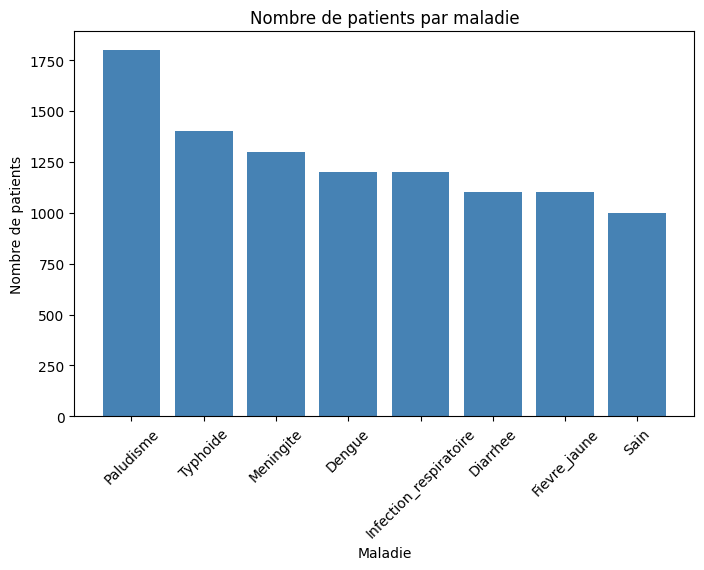

In [102]:
plt.figure(figsize=(8,5))
plt.bar(
    nombre_de_cas.index,
    nombre_de_cas.values,
    color = "steelblue"
)
plt.title("Nombre de patients par maladie")
plt.xlabel("Maladie")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

#### II)la temperature varie-t-elle selon la maladie ?

C:\Users\bobma\AppData\Local\Temp\ipykernel_10320\900860250.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groupes, labels = noms_des_maladies)


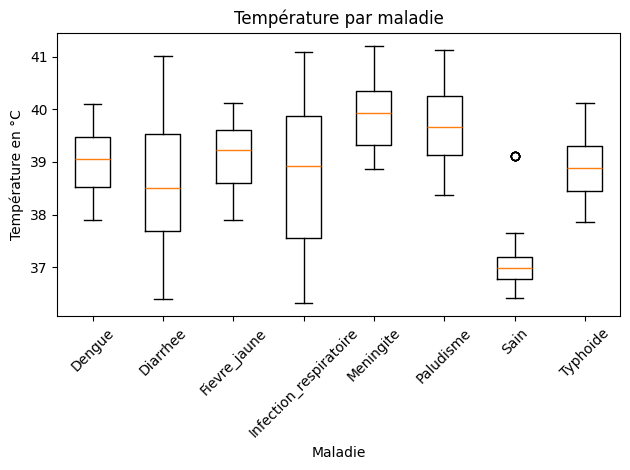

In [86]:
#les noms de maladies
noms_des_maladies = []
#on récupère les températures
groupes = []
for nom, groupe in df.groupby("Maladie"):
    noms_des_maladies.append(nom)
    groupes.append(groupe["Temperature"].values)

#visualisation
plt.boxplot(groupes, labels = noms_des_maladies)
plt.title("Température par maladie")
plt.xlabel("Maladie")
plt.ylabel("Température en °C")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


#### III)le heatmap des symptomes

In [ ]:
symptomes = []
for col in df.columns:
    if col not in  colonnes_a_exclure:
        symptomes.append(col)

Symptomes trouvés: ['Frissons', 'Maux_de_tete', 'Vomissements', 'Fatigue', 'Douleurs_musculaires', 'Toux', 'Symptome_diarrhee', 'Raideur_cou', 'Sudation', 'Douleurs_articulaires', 'Eruption_cutanee', 'Ictere', 'Douleurs_abdominales', 'Confusion', 'Photophobie', 'Mal_de_gorge', 'Ecoulement_nasal']
                          Frissons  Maux_de_tete  Vomissements     Fatigue  \
Maladie                                                                      
Dengue                   45.711907     46.711074     55.953372  100.000000   
Diarrhee                 56.494096     53.496821     45.231608   45.049955   
Fievre_jaune             53.000000     47.000000    100.000000  100.000000   
Infection_respiratoire   53.833333     54.416667     46.416667  100.000000   
Meningite                40.615385    100.000000     45.384615   45.538462   
Paludisme               100.000000    100.000000     47.084953  100.000000   
Sain                      0.100000      0.100000      0.000000    0.000000   


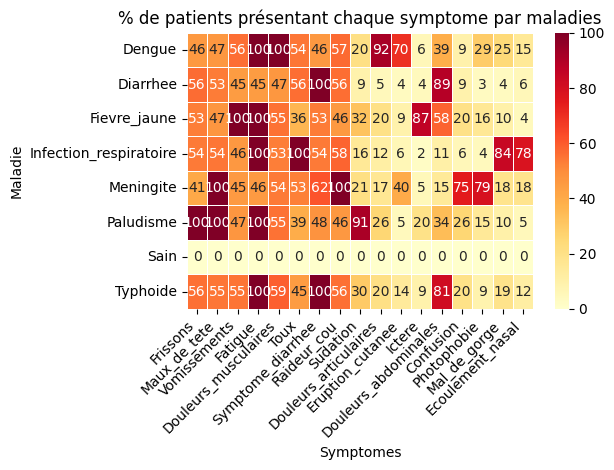

In [87]:
import seaborn as sns
colonnes_a_exclure = ["ID_Patient","Age","Sexe","Zone",
                      "Saison","Duree_Fievre_Jours",
                      "Temperature","Maladie"]
symptomes = [col for col in df.columns 
             if col not in colonnes_a_exclure]
print("Symptomes trouvés:", symptomes)
heatmap_donnees = df.groupby("Maladie")[symptomes].mean()*100
print(heatmap_donnees)
plt.Figure(figsize=(16,6))
sns.heatmap(
    heatmap_donnees,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title("% de patients présentant chaque symptome par maladies")
plt.xlabel("Symptomes")
plt.ylabel("Maladie")
plt.xticks(rotation = 45,ha = "right")
plt.tight_layout()
plt.show()

#### IV) le paludisme est-il plus présent pendant la saison des pluies ?

Saison                  Pluies  Seche
Maladie                              
Dengue                     887    314
Diarrhee                   566    535
Fievre_jaune               853    247
Infection_respiratoire     342    858
Meningite                  653    647
Paludisme                 1399    402
Sain                       491    509
Typhoide                   711    689


<Figure size 1200x600 with 0 Axes>

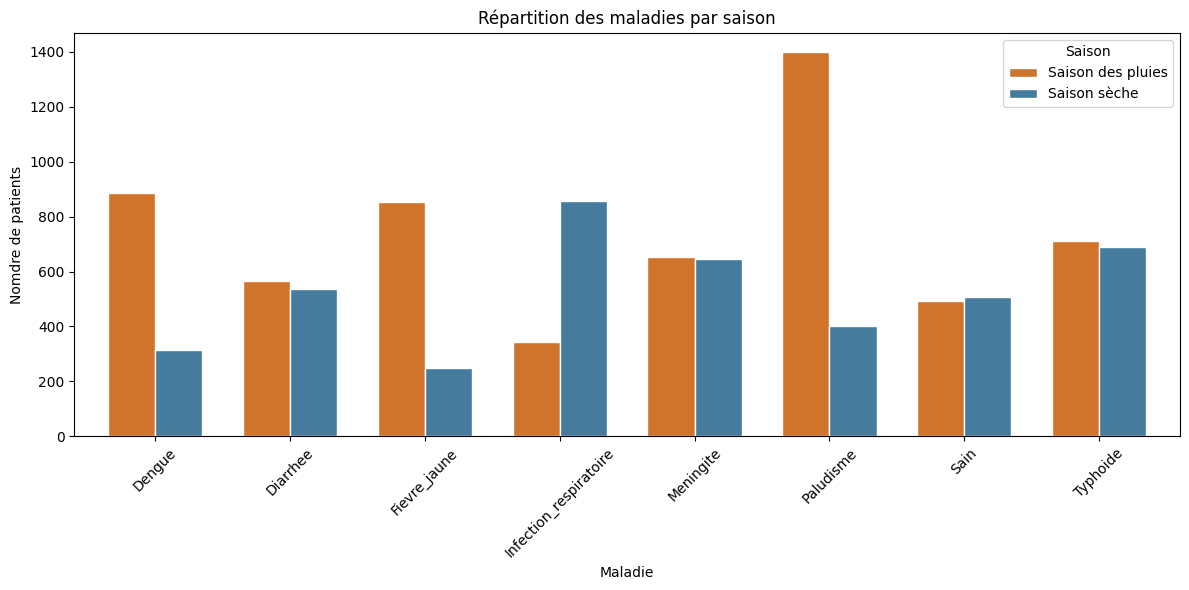

In [88]:
tableau = pd.crosstab(df["Maladie"],df["Saison"])
print(tableau)

plt.figure(figsize= (12,6))
tableau.plot(
    kind = "bar",
    figsize=(12,6),
    color=["#CF742A", '#457B9D'],
    width= 0.7,
    edgecolor= "white"
    
)
plt.title("Répartition des maladies par saison")
plt.xlabel("Maladie")
plt.ylabel("Nomdre de patients")
plt.xticks(rotation = 45,)
plt.legend(title="Saison", labels=["Saison des pluies","Saison sèche"])
plt.tight_layout()
plt.show()

#### V)quelles tranches d'ages sont les plus touchés

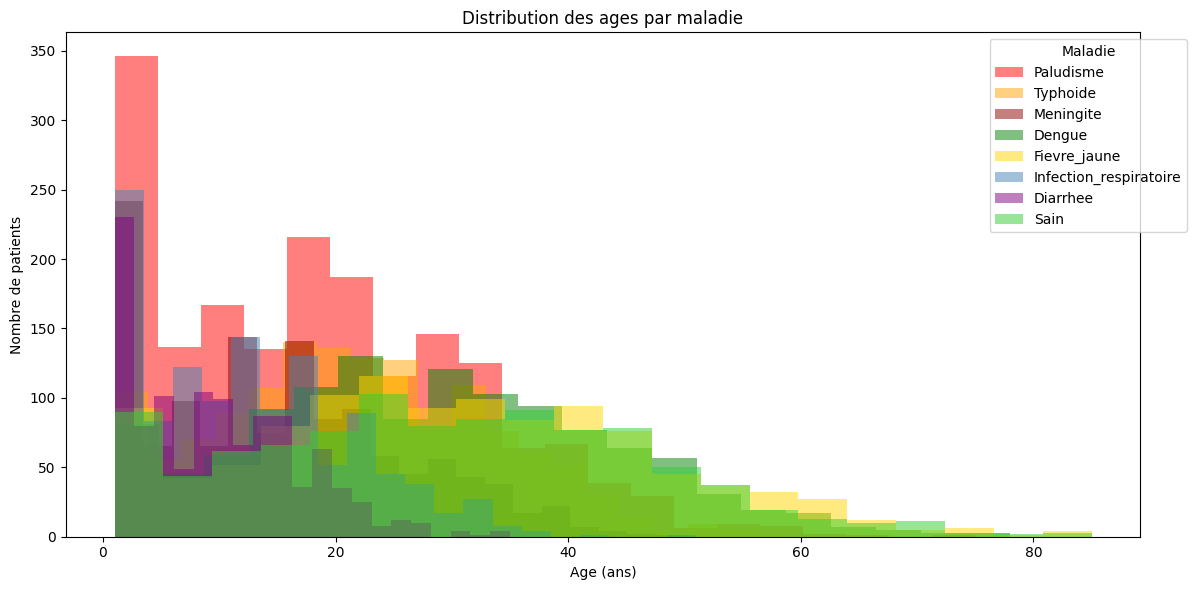

In [89]:
couleurs = {
    "Paludisme":              "red",
    "Typhoide":               "orange",
    "Meningite":              "darkred",
    "Dengue":                 "green",
    "Fievre_jaune":           "gold",
    "Infection_respiratoire": "steelblue",
    "Diarrhee":               "purple",
    "Sain":                   "limegreen",
}
plt.figure(figsize=(12,6))
for maladie, couleur in couleurs.items():
    ages = df[df["Maladie"]== maladie]["Age"]
    plt.hist(
        ages,
        bins=20,
        alpha=0.5,
        label=maladie,
        color=couleur
    )
plt.title("Distribution des ages par maladie")
plt.xlabel("Age (ans)")
plt.ylabel("Nombre de patients")
plt.legend(title="Maladie",bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
